In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
X_train = pd.read_csv(
'/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/data/X_train.csv'
)

X_test = pd.read_csv(
'/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/data/X_test.csv'
)

y_train = pd.read_csv(
'/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/data/y_train.csv'
)

y_test = pd.read_csv(
'/content/drive/MyDrive/ML_Projects/Customer_Default_Prediction/data/y_test.csv'
)

In [5]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [6]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(24000, 27)
(6000, 27)
(24000,)
(6000,)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [8]:
results=[]

model 1 : Logistic regression

In [9]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [10]:
y_pred = lr.predict(
    X_test_scaled
)

y_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

In [13]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("ROC-AUC :", roc_auc)

Accuracy : 0.8085
Precision : 0.6918103448275862
Recall : 0.24189902034664656
F1 : 0.35845896147403683
ROC-AUC : 0.7081429965888152


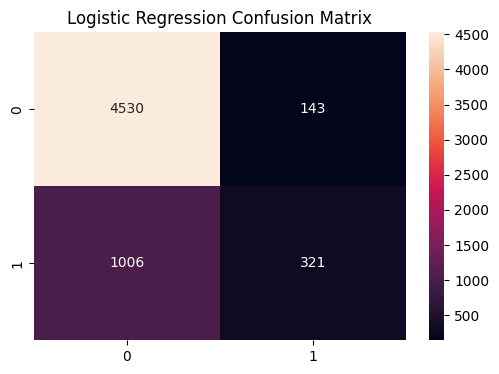

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

In [16]:
results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "ROC_AUC":roc_auc
})

In [17]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8085, 'Precision': 0.6918103448275862, 'Recall': 0.24189902034664656, 'F1': 0.35845896147403683, 'ROC_AUC': np.float64(0.7081429965888152)}]


model 2 : Decision tree

In [18]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
y_pred = dt.predict(X_test)

y_prob = dt.predict_proba(X_test)[:, 1]

Accuracy : 0.724
Precision : 0.38374558303886924
Recall : 0.4091936699321778
F1 : 0.39606126914660833
ROC-AUC : 0.6112948876089308


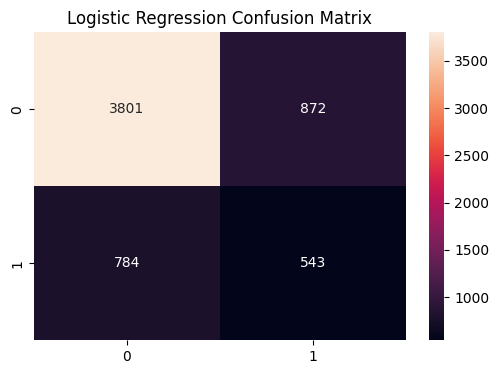

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4673
           1       0.38      0.41      0.40      1327

    accuracy                           0.72      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.72      0.73      6000



In [20]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("ROC-AUC :", roc_auc)


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

In [21]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
})

In [22]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8085, 'Precision': 0.6918103448275862, 'Recall': 0.24189902034664656, 'F1': 0.35845896147403683, 'ROC_AUC': np.float64(0.7081429965888152)}, {'Model': 'Decision Tree', 'Accuracy': 0.724, 'Precision': 0.38374558303886924, 'Recall': 0.4091936699321778, 'F1': 0.39606126914660833, 'ROC_AUC': np.float64(0.6112948876089308)}]


model 3 : Random forest

In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [24]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

Accuracy : 0.8136666666666666
Precision : 0.6410256410256411
Recall : 0.3579502637528259
F1 : 0.45938104448742745
ROC-AUC : 0.7575852622877565


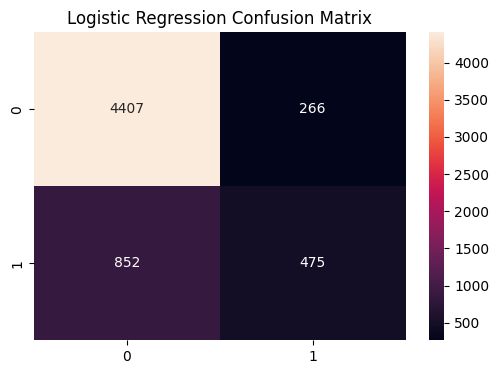

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("ROC-AUC :", roc_auc)


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

In [26]:
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
})

In [27]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8085, 'Precision': 0.6918103448275862, 'Recall': 0.24189902034664656, 'F1': 0.35845896147403683, 'ROC_AUC': np.float64(0.7081429965888152)}, {'Model': 'Decision Tree', 'Accuracy': 0.724, 'Precision': 0.38374558303886924, 'Recall': 0.4091936699321778, 'F1': 0.39606126914660833, 'ROC_AUC': np.float64(0.6112948876089308)}, {'Model': 'Random Forest', 'Accuracy': 0.8136666666666666, 'Precision': 0.6410256410256411, 'Recall': 0.3579502637528259, 'F1': 0.45938104448742745, 'ROC_AUC': np.float64(0.7575852622877565)}]


model 4: Gradient boosting

In [28]:


gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [29]:
y_pred = gb.predict(X_test)

y_prob = gb.predict_proba(X_test)[:, 1]

Accuracy : 0.8186666666666667
Precision : 0.6662030598052852
Recall : 0.36096458176337604
F1 : 0.4682306940371456
ROC-AUC : 0.7810852351150309


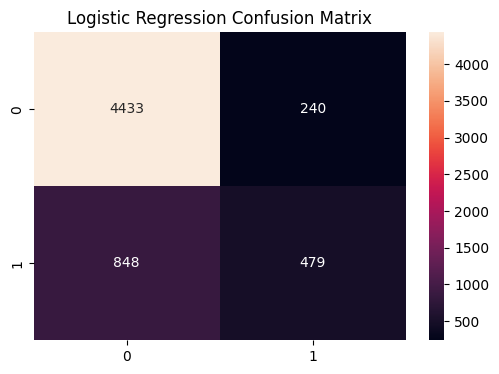

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [30]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("ROC-AUC :", roc_auc)


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


print(
    classification_report(
        y_test,
        y_pred
    )
)

In [31]:
results.append({
    "Model": "Gradient Boosting",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
})

In [32]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.8085, 'Precision': 0.6918103448275862, 'Recall': 0.24189902034664656, 'F1': 0.35845896147403683, 'ROC_AUC': np.float64(0.7081429965888152)}, {'Model': 'Decision Tree', 'Accuracy': 0.724, 'Precision': 0.38374558303886924, 'Recall': 0.4091936699321778, 'F1': 0.39606126914660833, 'ROC_AUC': np.float64(0.6112948876089308)}, {'Model': 'Random Forest', 'Accuracy': 0.8136666666666666, 'Precision': 0.6410256410256411, 'Recall': 0.3579502637528259, 'F1': 0.45938104448742745, 'ROC_AUC': np.float64(0.7575852622877565)}, {'Model': 'Gradient Boosting', 'Accuracy': 0.8186666666666667, 'Precision': 0.6662030598052852, 'Recall': 0.36096458176337604, 'F1': 0.4682306940371456, 'ROC_AUC': np.float64(0.7810852351150309)}]


In [33]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,PAY_0,0.627065
7,PAY_2,0.065114
26,PAYMENT_RATIO,0.034510
8,PAY_3,0.030438
1,LIMIT_BAL,0.024059
12,BILL_AMT1,0.023746
25,TOTAL_PAYMENT,0.023094
9,PAY_4,0.019298
10,PAY_5,0.018732
11,PAY_6,0.018552


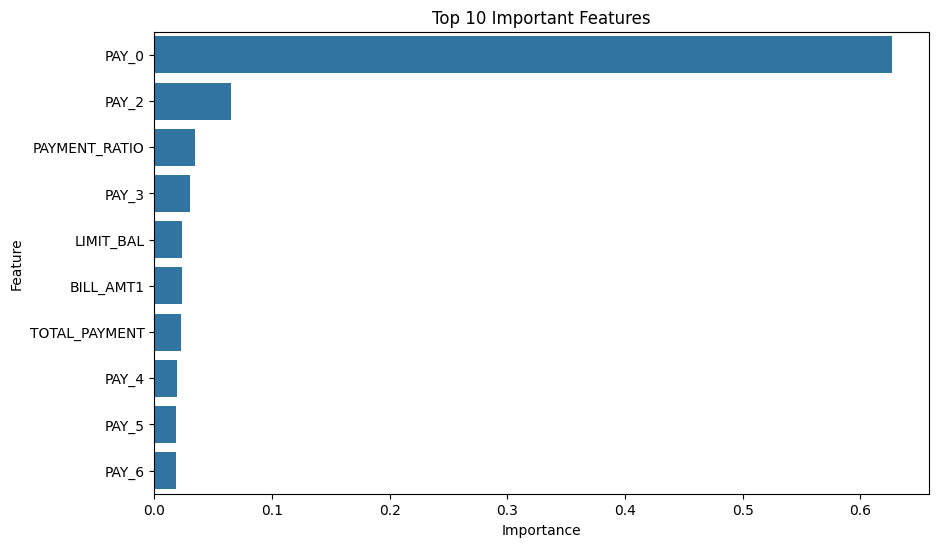

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()